# Paper Figures — Collective-Kernel EFT for Pre-activation ResNets

Reproduces all four figures in the paper.

| Figure | Output file | Content |
|--------|-------------|---------|
| Fig 1  | `figs/fig1_K0_V4.pdf`         | K₀ and V₄ trajectories vs empirical mean / covariance |
| Fig 2  | `figs/fig2_V4_eps_sweep.pdf`  | V₄ ε-independence: trajectories and relative error |
| Fig 3  | `figs/fig3_K1.pdf`            | Keff (NLO mean-kernel correction) |
| Fig 4  | `figs/fig4_U1_source.pdf`     | U₁ source comparison: exact vs EFT model |

**Settings (Fig 1, 3, 4)**: N=4, n=64, tanh, Cw=2, Cb=0, ε=0.05, L=800 (T=2.0), M=5×10⁶.  
**Settings (Fig 2)**: N=4, n=256, tanh, ε ∈ {0.10, 0.07, 0.05}, T=2.0, M=5×10⁵.

**Expected runtime**: ~4–6 hours on CPU.  
Reduce `M_MAIN=50_000` and `L_MAIN=200` for a quick test.


In [ ]:
import os, time
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs('../results', exist_ok=True)
os.makedirs('../figs', exist_ok=True)

from resnet_eft import Params, resnet_step, create_resnet_initial_state, ActivationSpec
from resnet_eft.gaussian_expectation import GaussianExpectation
from resnet_eft.k1_source_op import K1SourceOp
from resnet_eft.v4_repr import V4Tensor

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 9,
    'axes.labelsize': 10, 'axes.titlesize': 10,
    'legend.fontsize': 7.5, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'lines.linewidth': 1.5, 'lines.markersize': 4,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.5,
})
C = {
    'emp':   '#222222',   # empirical: near-black
    'u1ex':  '#2166AC',   # K1 from U1_exact: blue
    'eft':   '#D6604D',   # K1_EFT / V4 full: red-orange
    'v4src': '#4DAF4A',   # V4 source-only: green
    'u1mod': '#8B2FC9',   # U1_model: purple
}
print('Imports OK')


Imports OK


In [2]:
DTYPE  = torch.float64
FDTYPE = torch.float32

# ── Main run parameters (Fig 1, 3, 4) ───────────────────────────
N          = 4
n_hidden   = 64
Cw, Cb     = 2.0, 0.0
eps        = 0.05
L_MAIN     = 800       # T = eps^2 * L = 2.0
M_MAIN     = 5_000_000
batch_size = 2_000

rho = 0.3
K0_input = (1.0 - rho) * torch.eye(N, dtype=DTYPE) * 2.0 \
         + rho * torch.ones(N, N, dtype=DTYPE) * 2.0

params = Params(act=ActivationSpec.tanh(), Cw=Cw, Cb=Cb)
gauss  = GaussianExpectation(params)
L_chol = torch.linalg.cholesky(K0_input)

L          = L_MAIN
M          = M_MAIN
num_batches = M // batch_size

depths_main = np.arange(L_MAIN + 1)
times_main  = eps**2 * depths_main
times       = times_main

print(f'Main: N={N}, n={n_hidden}, eps={eps}, L={L}, T={eps**2*L:.2f}, M={M:,}')


Main: N=4, n=64, eps=0.05, L=800, T=2.00, M=5,000,000


In [3]:
# ── Helper: Sigma(K) = leading-order n*Cov(H|phi) ────────────────────────────
# Sigma_{ab,cd}(K) = K_{ac}Q_{bd} + K_{ad}Q_{bc} + K_{bc}Q_{ad} + K_{bd}Q_{ac}

def compute_Sigma(K):
    Q = Cw * gauss.E2_pairwise(K)   # Q(K) = Cw*E2  (Cb=0)
    S = (torch.einsum('ac,bd->abcd', K, Q)
       + torch.einsum('ad,bc->abcd', K, Q)
       + torch.einsum('bc,ad->abcd', K, Q)
       + torch.einsum('bd,ac->abcd', K, Q))
    return S

print('compute_Sigma defined')

compute_Sigma defined


In [4]:
# ── Theory phase: K0, V4, K1_EFT ─────────────────────────────────────────────
t0 = time.time()

# --- K0 and V4 full trajectories ---
state = create_resnet_initial_state(K0_input, n_hidden, params, include_wishart_v4=True)
K0_traj        = [K0_input.clone()]
V4_full_traj   = [state.V4.as_tensor().clone()]

for _ in range(L):
    state = resnet_step(state, params, eps=eps, compute_K1=False, compute_V4=True)
    K0_traj.append(state.K0.clone())
    V4_full_traj.append(state.V4.as_tensor().clone())
print(f'K0/V4 full: {time.time()-t0:.1f}s')

# --- V4 source-only: dV4/dt = Sigma(K0)  (no chi transport) ---
V4_src_traj = [V4_full_traj[0].clone()]   # same Wishart initial condition
V4_src_now  = V4_src_traj[0].clone()
for ell in range(L):
    V4_src_now = V4_src_now + eps**2 * compute_Sigma(K0_traj[ell])
    V4_src_traj.append(V4_src_now.clone())
print(f'V4 source-only: {time.time()-t0:.1f}s')

# --- E2 trajectory (needed for U1_exact) ---
E2_traj = [gauss.E2_pairwise(K0_traj[ell]) for ell in range(L + 1)]

# --- Precompute chi and K1SourceOps ---
t1 = time.time()
chi_ops    = [gauss.build_chi_op(K0_traj[ell]) for ell in range(L)]
k1_src_ops = [K1SourceOp(K0_traj[ell], gauss) for ell in range(L)]
K1_src_th  = [k1_src_ops[ell].contract(V4Tensor(data=V4_full_traj[ell]), Cw)
              for ell in range(L)]
print(f'Operators precomputed: {time.time()-t1:.1f}s')

# --- K1_EFT: D2 Full (theory K0 + theory V4) ---
K1_eft = [torch.zeros(N, N, dtype=DTYPE)]
for ell in range(L):
    k = K1_eft[-1] + eps**2 * (chi_ops[ell].apply_pair(K1_eft[-1]) + K1_src_th[ell])
    K1_eft.append(k)

print(f'Theory phase total: {time.time()-t0:.1f}s')
print(f'K0[{L}][0,0]       = {K0_traj[L][0,0]:.4f}')
print(f'V4_full[{L}][0,0,0,0] = {V4_full_traj[L][0,0,0,0]:.4f}')
print(f'K1_eft[{L}][0,0]   = {K1_eft[L][0,0]:.4f}')

K0/V4 full: 86.5s
V4 source-only: 104.4s
Operators precomputed: 427.0s
Theory phase total: 549.0s
K0[800][0,0]       = 4.3730
V4_full[800][0,0,0,0] = 42.8779
K1_eft[800][0,0]   = -0.9011


In [5]:
# ── Main ensemble (batched Cholesky trick) ────────────────────────────────────
G_sum   = [torch.zeros(N, N,       dtype=DTYPE) for _ in range(L + 1)]
GG_sum  = [torch.zeros(N, N, N, N, dtype=DTYPE) for _ in range(L + 1)]
Sig_sum = [torch.zeros(N, N,       dtype=DTYPE) for _ in range(L)]

L_chol_f = L_chol.to(FDTYPE)
t0 = time.time()

for b in range(num_batches):
    torch.manual_seed(b * 97 + 1)
    phi = torch.randn(batch_size, n_hidden, N, dtype=FDTYPE) @ L_chol_f.T   # (B,n,N)

    G_b = torch.bmm(phi.transpose(-2,-1), phi) / n_hidden                   # (B,N,N)
    G_sum[0]  += G_b.sum(0).to(DTYPE)
    Gf = G_b.reshape(batch_size, N * N)
    GG_sum[0] += (Gf.T @ Gf).reshape(N, N, N, N).to(DTYPE)

    for ell in range(L):
        sig = torch.tanh(phi)                                                # (B,n,N)
        A   = torch.bmm(sig.transpose(-2,-1), sig) * (Cw / n_hidden)        # (B,N,N)
        Sig_sum[ell] += (A / Cw).sum(0).to(DTYPE)   # sum of S^ell = sig^T sig / n
        A.diagonal(dim1=-2, dim2=-1).add_(1e-8)
        L_A = torch.linalg.cholesky(A)                                       # (B,N,N)
        Z   = torch.randn(batch_size, n_hidden, N, dtype=FDTYPE)
        phi = phi + eps * torch.bmm(Z, L_A.transpose(-2,-1))                 # (B,n,N)

        G_b = torch.bmm(phi.transpose(-2,-1), phi) / n_hidden
        G_sum[ell+1]  += G_b.sum(0).to(DTYPE)
        Gf = G_b.reshape(batch_size, N * N)
        GG_sum[ell+1] += (Gf.T @ Gf).reshape(N, N, N, N).to(DTYPE)

    if (b + 1) % 10 == 0:
        el  = time.time() - t0
        eta = el / (b+1) * (num_batches - b - 1)
        print(f'  Batch {b+1:3d}/{num_batches}  elapsed={el:.0f}s  ETA={eta:.0f}s')

G_mean   = [G_sum[ell]   / M for ell in range(L + 1)]
GG_mean  = [GG_sum[ell]  / M for ell in range(L + 1)]
Sig_mean = [Sig_sum[ell] / M for ell in range(L)]

print(f'\nEnsemble done: {time.time()-t0:.1f}s')
print(f'G_mean[0][0,0]   = {G_mean[0][0,0]:.4f}  (K0 = {K0_input[0,0]:.4f})')
print(f'G_mean[{L}][0,0]  = {G_mean[L][0,0]:.4f}  (K0_th = {K0_traj[L][0,0]:.4f})')
print(f'Sig_mean[0][0,0] = {Sig_mean[0][0,0]:.4f}  (E2 = {E2_traj[0][0,0]:.4f})')

  Batch  10/2500  elapsed=76s  ETA=18885s
  Batch  20/2500  elapsed=152s  ETA=18854s
  Batch  30/2500  elapsed=229s  ETA=18815s
  Batch  40/2500  elapsed=305s  ETA=18759s
  Batch  50/2500  elapsed=382s  ETA=18702s
  Batch  60/2500  elapsed=458s  ETA=18643s
  Batch  70/2500  elapsed=535s  ETA=18581s
  Batch  80/2500  elapsed=612s  ETA=18512s
  Batch  90/2500  elapsed=689s  ETA=18446s
  Batch 100/2500  elapsed=766s  ETA=18374s
  Batch 110/2500  elapsed=842s  ETA=18304s
  Batch 120/2500  elapsed=919s  ETA=18231s
  Batch 130/2500  elapsed=996s  ETA=18159s
  Batch 140/2500  elapsed=1073s  ETA=18088s
  Batch 150/2500  elapsed=1150s  ETA=18016s
  Batch 160/2500  elapsed=1227s  ETA=17942s
  Batch 170/2500  elapsed=1304s  ETA=17869s
  Batch 180/2500  elapsed=1381s  ETA=17796s
  Batch 190/2500  elapsed=1458s  ETA=17722s
  Batch 200/2500  elapsed=1535s  ETA=17647s
  Batch 210/2500  elapsed=1612s  ETA=17574s
  Batch 220/2500  elapsed=1689s  ETA=17500s
  Batch 230/2500  elapsed=1766s  ETA=17425s
  

In [6]:
# ── Post-processing ───────────────────────────────────────────────────────────

# K1_mic[ell] = n * (G_mean[ell] - K0_traj[ell])   (microscopic empirical K1)
K1_mic = [n_hidden * (G_mean[ell] - K0_traj[ell]) for ell in range(L + 1)]

# V4_emp[ell] = n * Var(G[ell])
V4_emp = [
    n_hidden * (GG_mean[ell] - torch.einsum('ab,cd->abcd', G_mean[ell], G_mean[ell]))
    for ell in range(L + 1)
]

# Standard error of K1_mic: SE[a,b] = sqrt(V4_emp[a,b,a,b] / (M/n))
K1_se = [
    (torch.einsum('abab->ab', V4_emp[ell]) * n_hidden / M).clamp(min=0).sqrt()
    for ell in range(L + 1)
]

# U1_exact[ell] = n * (Sig_mean[ell] - E2(K0[ell]))
U1_exact = [n_hidden * (Sig_mean[ell] - E2_traj[ell]) for ell in range(L)]

# K1 from exact source: K1_u1ex[ell+1] = K1_u1ex[ell] + eps^2 * Cw * U1_exact[ell]
K1_u1ex = [torch.zeros(N, N, dtype=DTYPE)]
for ell in range(L):
    K1_u1ex.append(K1_u1ex[-1] + eps**2 * Cw * U1_exact[ell])

# U1_model = (1/Cw)*chi[K1_eft] + (1/2Cw)*Hess:V4  = chi[K1_eft]/Cw + K1_src_th/Cw
U1_model = [
    (chi_ops[ell].apply_pair(K1_eft[ell]) + K1_src_th[ell]) / Cw
    for ell in range(L)
]

print('Post-processing done.')
print(f'U1_exact[0][0,0] = {U1_exact[0][0,0]:.6f}  (theorem: exactly 0)')
print(f'U1_model[0][0,0] = {U1_model[0][0,0]:.4f}  (EFT, should != 0)')
print(f'K1_mic [{L}][0,0] = {K1_mic[L][0,0]:.4f}  +/- {K1_se[L][0,0]:.4f}')
print(f'K1_u1ex[{L}][0,0] = {K1_u1ex[L][0,0]:.4f}')
print(f'K1_eft [{L}][0,0] = {K1_eft[L][0,0]:.4f}')

Post-processing done.
U1_exact[0][0,0] = -0.009546  (theorem: exactly 0)
U1_model[0][0,0] = -0.1975  (EFT, should != 0)
K1_mic [800][0,0] = -0.7742  +/- 0.0250
K1_u1ex[800][0,0] = -0.7812
K1_eft [800][0,0] = -0.9011


## Figure 1 — K₀ and V₄ Trajectories

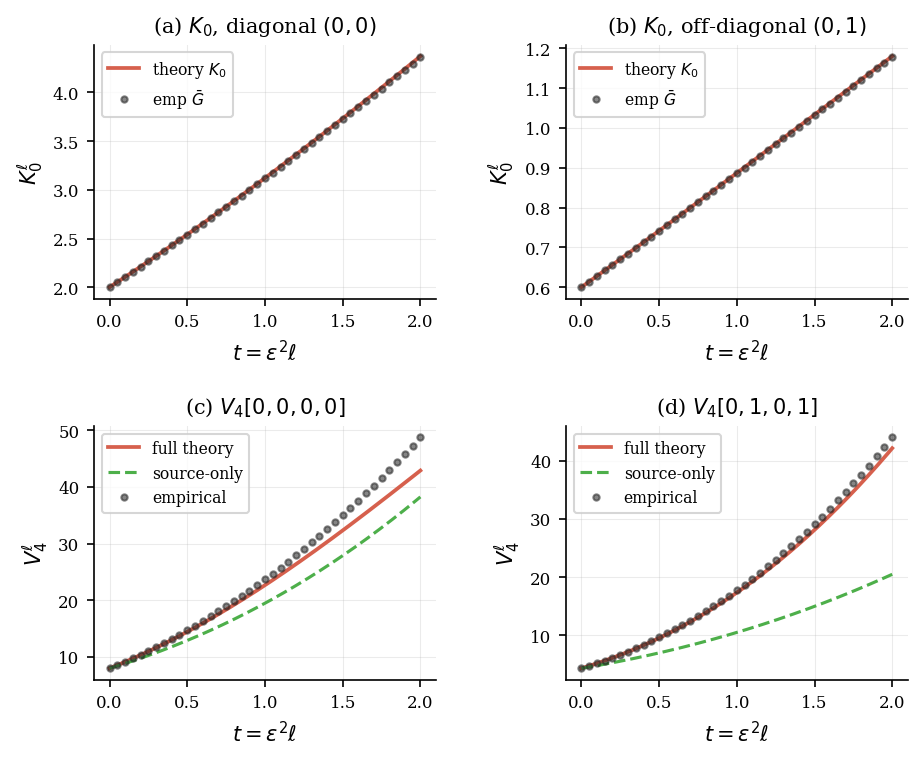

Saved fig1_K0_V4

V4 relative errors (full theory vs empirical), component [0,0,0,0]:
  ell=  0 t=0.00: V4_full=8.000, V4_emp=8.005, rel_err=-0.0007
  ell=200 t=0.50: V4_full=14.447, V4_emp=14.719, rel_err=-0.0185
  ell=400 t=1.00: V4_full=22.663, V4_emp=23.687, rel_err=-0.0432
  ell=600 t=1.50: V4_full=32.313, V4_emp=35.010, rel_err=-0.0770
  ell=800 t=2.00: V4_full=42.878, V4_emp=48.735, rel_err=-0.1202


In [7]:
# ── Figure 2: K0 and V4 trajectories ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(7, 5.5))
fig.subplots_adjust(hspace=0.5, wspace=0.38)

# Helper: sub-sample marker positions
me = 20   # markevery

for col, (a, b) in enumerate([(0, 0), (0, 1)]):
    lbl = f'$({a},{b})$'

    # ── K0 row ──────────────────────────────────────────────────────────────
    ax = axes[0, col]
    y_th  = [K0_traj[ell][a,b].item()  for ell in range(L+1)]
    y_emp = [G_mean[ell][a,b].item()   for ell in range(L+1)]

    ax.plot(times, y_th,  color=C['eft'],  lw=1.8, label='theory $K_0$', zorder=3)
    ax.plot(times, y_emp, color=C['emp'],  lw=0, marker='o',
            markersize=3, alpha=0.55, markevery=me, label=r'emp $\bar{G}$', zorder=4)
    ax.set_xlabel(r'$t=\varepsilon^2\ell$')
    ax.set_ylabel(r'$K_0^\ell$')
    ax.set_title(f'({"+abcd"[col*2]}) $K_0$, ' + lbl)
    ax.legend()

    # ── V4 row ──────────────────────────────────────────────────────────────
    ax = axes[1, col]
    y_full = [V4_full_traj[ell][a,b,a,b].item() for ell in range(L+1)]
    y_src  = [V4_src_traj[ell][a,b,a,b].item()  for ell in range(L+1)]
    y_emp  = [V4_emp[ell][a,b,a,b].item()        for ell in range(L+1)]

    ax.plot(times, y_full, color=C['eft'],   lw=1.8,         label='full theory', zorder=3)
    ax.plot(times, y_src,  color=C['v4src'], lw=1.5, ls='--', label='source-only', zorder=3)
    ax.plot(times, y_emp,  color=C['emp'],   lw=0, marker='o',
            markersize=3, alpha=0.55, markevery=me, label='empirical', zorder=4)
    ax.set_xlabel(r'$t=\varepsilon^2\ell$')
    ax.set_ylabel(r'$V_4^\ell$')
    ax.set_title(f'({"+abcd"[col*2+1]}) $V_4[{a},{b},{a},{b}]$')
    ax.legend()

# fix panel labels
axes[0,0].set_title(r'(a) $K_0$, diagonal $(0,0)$')
axes[0,1].set_title(r'(b) $K_0$, off-diagonal $(0,1)$')
axes[1,0].set_title(r'(c) $V_4[0,0,0,0]$')
axes[1,1].set_title(r'(d) $V_4[0,1,0,1]$')

plt.savefig('../figs/fig1_K0_V4.pdf')
plt.savefig('../figs/fig1_K0_V4.png', dpi=200)
plt.show()
print('Saved fig1_K0_V4')

# ── V4 relative error diagnostic ──────────────────────────────────────────
T_end = eps**2 * L
print(f'\nV4 relative errors (full theory vs empirical), component [0,0,0,0]:')
for ell in [0, L//4, L//2, 3*L//4, L]:
    v4f = V4_full_traj[ell][0,0,0,0].item()
    v4e = V4_emp[ell][0,0,0,0].item()
    print(f'  ell={ell:3d} t={times[ell]:.2f}: V4_full={v4f:.3f}, V4_emp={v4e:.3f}, rel_err={(v4f-v4e)/max(abs(v4e),1e-6):.4f}')

## Figure 2 — V₄ ε-Independence (ε-Sweep)

In [8]:
# ── ε-sweep parameters (Fig 2) ──────────────────────────────────
EPS_LIST = [0.10, 0.07, 0.05]
M_EPS    = 500_000
N_EPS    = 256
T_MAX    = 2.0

def run_eps_config(n, eps_val, M, batch_sz=500):
    """Run theory + ensemble for given (n, eps); T fixed to T_MAX."""
    L = round(T_MAX / eps_val**2)
    t = eps_val**2 * np.arange(L + 1)
    state = create_resnet_initial_state(K0_input, n, params, include_wishart_v4=True)
    V4_th = [state.V4.as_tensor().clone()]
    for _ in range(L):
        state = resnet_step(state, params, eps=eps_val,
                            compute_V4=True, compute_K1=False)
        V4_th.append(state.V4.as_tensor().clone())

    L_chol_f = L_chol.to(FDTYPE)
    G_sum  = [torch.zeros(N, N,       dtype=DTYPE) for _ in range(L+1)]
    GG_sum = [torch.zeros(N, N, N, N, dtype=DTYPE) for _ in range(L+1)]
    for b in range(M // batch_sz):
        torch.manual_seed(b * 97 + 1)
        phi = torch.randn(batch_sz, n, N, dtype=FDTYPE) @ L_chol_f.T
        G_b = torch.bmm(phi.transpose(-2,-1), phi) / n
        G_sum[0] += G_b.sum(0).to(DTYPE)
        GG_sum[0] += (G_b.reshape(batch_sz,N*N).T @ G_b.reshape(batch_sz,N*N)).reshape(N,N,N,N).to(DTYPE)
        for ell in range(L):
            sig = torch.tanh(phi)
            A   = torch.bmm(sig.transpose(-2,-1), sig) * (Cw / n)
            A.diagonal(dim1=-2, dim2=-1).add_(1e-8)
            phi = phi + eps_val * torch.bmm(torch.randn(batch_sz, n, N, dtype=FDTYPE),
                                            torch.linalg.cholesky(A).transpose(-2,-1))
            G_b = torch.bmm(phi.transpose(-2,-1), phi) / n
            G_sum[ell+1]  += G_b.sum(0).to(DTYPE)
            GG_sum[ell+1] += (G_b.reshape(batch_sz,N*N).T @ G_b.reshape(batch_sz,N*N)).reshape(N,N,N,N).to(DTYPE)

    G_mean = [G_sum[ell] / M for ell in range(L+1)]
    GG_mean = [GG_sum[ell] / M for ell in range(L+1)]
    V4_emp = [n*(GG_mean[ell] - torch.einsum('ab,cd->abcd', G_mean[ell], G_mean[ell]))
              for ell in range(L+1)]
    return dict(eps=eps_val, L=L, times=t, V4_th=V4_th, V4_emp=V4_emp)

print('run_eps_config defined')


run_eps_config defined


In [9]:
results_eps = {}
for eps_val in EPS_LIST:
    print(f'Running eps={eps_val}...')
    results_eps[eps_val] = run_eps_config(N_EPS, eps_val, M_EPS)
    r = results_eps[eps_val]
    v4e = float(r['V4_emp'][-1][0,0,0,0])
    v4t = float(r['V4_th'][-1][0,0,0,0])
    re  = (v4t - v4e) / max(abs(v4e), 1e-6)
    print(f'  eps={eps_val}: rel_err={re:+.4f} ({100*re:.1f}%)')
print('ε-sweep done')


Running eps=0.1...
  eps=0.1: rel_err=-0.1162 (-11.6%)
Running eps=0.07...
  eps=0.07: rel_err=-0.1155 (-11.6%)
Running eps=0.05...
  eps=0.05: rel_err=-0.1150 (-11.5%)
ε-sweep done


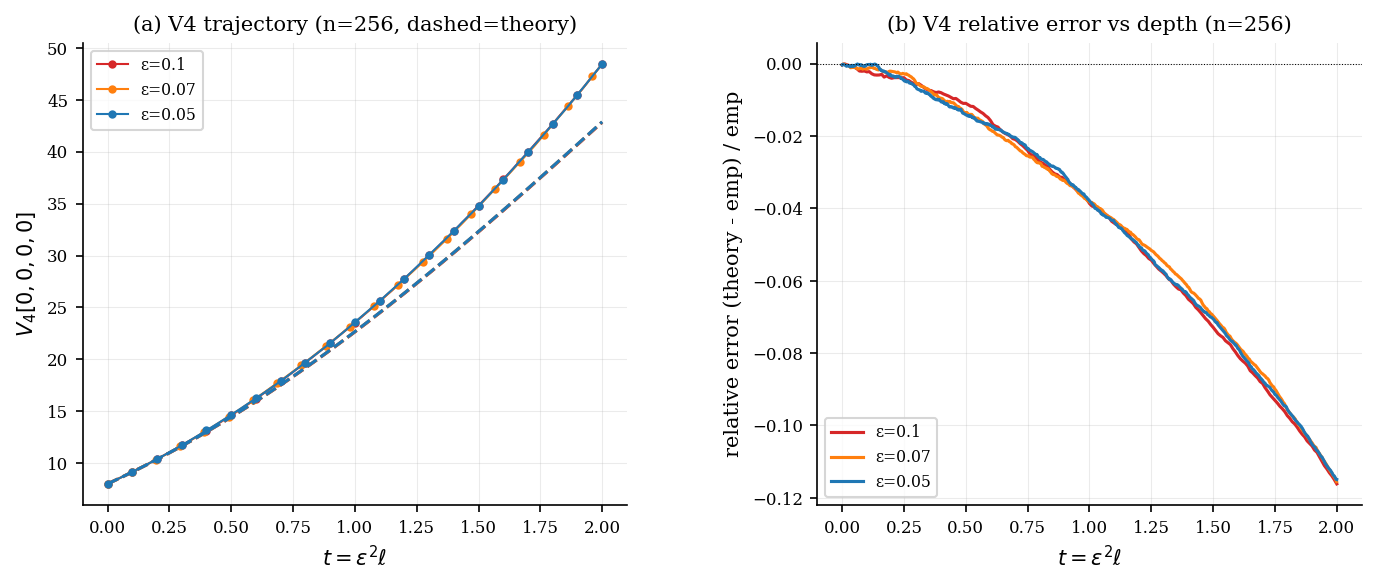

Saved fig2


In [10]:
# ── Figure 1: V4 trajectory comparison (eps sweep, n=256) ─────────────────
colors = {0.10: '#d62728', 0.07: '#ff7f0e', 0.05: '#1f77b4'}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.subplots_adjust(wspace=0.35)

ax = axes[0]
for eps_val in EPS_LIST:
    r = results_eps[eps_val]
    t = r['times']
    me = max(1, r['L'] // 20)
    y_th  = [r['V4_th'][ell][0,0,0,0].item()  for ell in range(r['L']+1)]
    y_emp = [r['V4_emp'][ell][0,0,0,0].item() for ell in range(r['L']+1)]
    ax.plot(t, y_th,  color=colors[eps_val], lw=1.5, ls='--')
    ax.plot(t, y_emp, color=colors[eps_val], lw=1.0, marker='o',
            markersize=3, markevery=me, label=f'ε={eps_val}')

ax.set_xlabel(r'$t = \varepsilon^2 \ell$')
ax.set_ylabel(r'$V_4[0,0,0,0]$')
ax.set_title('(a) V4 trajectory (n=256, dashed=theory)')
ax.legend()

ax = axes[1]
for eps_val in EPS_LIST:
    r = results_eps[eps_val]
    t = r['times']
    rel = [(r['V4_th'][ell][0,0,0,0].item() - r['V4_emp'][ell][0,0,0,0].item())
           / max(abs(r['V4_emp'][ell][0,0,0,0].item()), 1e-6)
           for ell in range(r['L']+1)]
    ax.plot(t, rel, color=colors[eps_val], lw=1.5, label=f'ε={eps_val}')

ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel(r'$t = \varepsilon^2 \ell$')
ax.set_ylabel('relative error (theory - emp) / emp')
ax.set_title('(b) V4 relative error vs depth (n=256)')
ax.legend()

plt.savefig('../figs/fig2_V4_eps_sweep.pdf')
plt.savefig('../figs/fig2_V4_eps_sweep.png', dpi=150)
plt.show()
print('Saved fig2')

## Figure 3 — Keff (NLO Mean-Kernel Correction)

  K1 (0, 0): SNR(K1_mic)~31.0, SE_max=0.0250, K1_mic[0]=0.0045 (expected 0; SE~0.0101), H-noise~0.0101
  K1 (0, 1): SNR(K1_mic)~4.2, SE_max=0.0237, K1_mic[0]=-0.0026 (expected 0; SE~0.0075), H-noise~0.0101


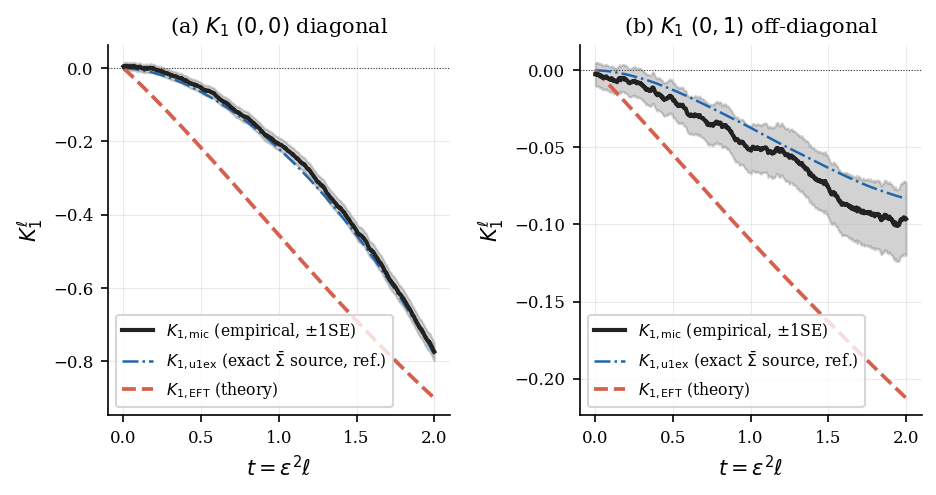

Saved fig3_K1_main


In [11]:
# ── Figure 3: K1 main result ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
fig.subplots_adjust(wspace=0.38)

for ax, (a, b), panel in zip(axes, [(0,0),(0,1)], ['a','b']):
    x      = times
    y_mic  = np.array([K1_mic[ell][a,b].item()   for ell in range(L+1)])
    y_u1ex = np.array([K1_u1ex[ell][a,b].item()  for ell in range(L+1)])
    y_eft  = np.array([K1_eft[ell][a,b].item()   for ell in range(L+1)])
    se     = np.array([K1_se[ell][a,b].item()     for ell in range(L+1)])

    # K1_mic  = primary empirical value: n*(G_mean - K0), direct measurement.
    # K1_u1ex = reference: exact K1 ODE driven by measured Sigma_mean.
    #           Avoids H-mean accumulation noise; used to diagnose why EFT fails.
    snr_mic  = abs(y_mic).max() / se.max()
    h_noise  = 2 * eps * np.sqrt(L * n_hidden / M)
    print(f'  K1 {(a,b)}: SNR(K1_mic)~{snr_mic:.1f}, SE_max={se.max():.4f}, '
          f'K1_mic[0]={y_mic[0]:.4f} (expected 0; SE~{se[0]:.4f}), H-noise~{h_noise:.4f}')

    ax.fill_between(x, y_mic - se, y_mic + se,
                    color=C['emp'], alpha=0.20, zorder=1)
    ax.plot(x, y_mic, color=C['emp'],  lw=2.0,
            label=r'$K_{1,\rm mic}$ (empirical, $\pm$1SE)', zorder=5)
    ax.plot(x, y_u1ex, color=C['u1ex'], lw=1.2, ls='-.',
            label=r'$K_{1,\rm u1ex}$ (exact $\bar{\Sigma}$ source, ref.)', zorder=3)
    ax.plot(x, y_eft,  color=C['eft'],  lw=1.8, ls='--',
            label=r'$K_{1,\rm EFT}$ (theory)', zorder=4)
    ax.axhline(0, color='k', lw=0.5, ls=':', zorder=0)

    lbl = '$(0,0)$ diagonal' if (a,b)==(0,0) else '$(0,1)$ off-diagonal'
    ax.set_xlabel(r'$t = \varepsilon^2\ell$')
    ax.set_ylabel(r'$K_1^\ell$')
    ax.set_title(f'({panel}) $K_1$ ' + lbl)
    ax.legend()

plt.savefig('../figs/fig3_K1.pdf')
plt.savefig('../figs/fig3_K1.png', dpi=200)
plt.show()
print('Saved fig3_K1_main')

## Figure 4 — U₁ Source Comparison

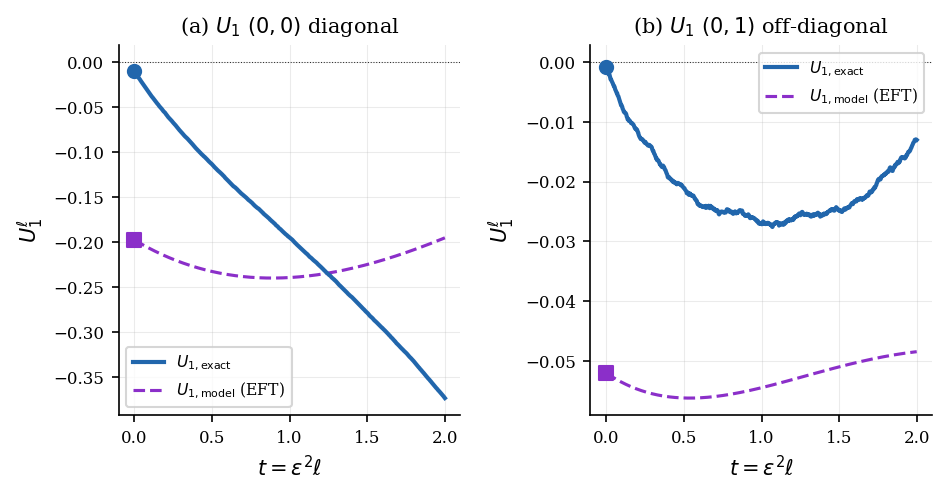

Saved fig4_U1_source


In [12]:
# ── Figure 4: U1 source comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
fig.subplots_adjust(wspace=0.38)

x = times[:-1]   # ell = 0 .. L-1

for ax, (a, b), panel in zip(axes, [(0,0),(0,1)], ['a','b']):
    y_ex  = np.array([U1_exact[ell][a,b].item() for ell in range(L)])
    y_mod = np.array([U1_model[ell][a,b].item() for ell in range(L)])

    ax.plot(x, y_ex,  color=C['u1ex'],  lw=2.0,          label=r'$U_{1,\rm exact}$', zorder=4)
    ax.plot(x, y_mod, color=C['u1mod'], lw=1.5, ls='--', label=r'$U_{1,\rm model}$ (EFT)', zorder=3)
    ax.axhline(0, color='k', lw=0.5, ls=':', zorder=0)

    # Mark ell=0 mismatch
    ax.scatter([x[0]], [y_ex[0]],  color=C['u1ex'],  s=40, zorder=6)
    ax.scatter([x[0]], [y_mod[0]], color=C['u1mod'], s=40, marker='s', zorder=6)

    lbl = '$(0,0)$ diagonal' if (a,b)==(0,0) else '$(0,1)$ off-diagonal'
    ax.set_xlabel(r'$t = \varepsilon^2\ell$')
    ax.set_ylabel(r'$U_1^\ell$')
    ax.set_title(f'({panel}) $U_1$ ' + lbl)
    ax.legend()

plt.savefig('../figs/fig4_U1_source.pdf')
plt.savefig('../figs/fig4_U1_source.png', dpi=200)
plt.show()
print('Saved fig4_U1_source')

## Table 3 — Σ_mic vs Σ(K₀) (§6.4, n=256, M=500K)

Verifies that the theoretical source approximation $\Sigma(K_0^\ell)$ matches the
microscopic estimator $\Sigma_{\mathrm{mic}}^\ell$ at five representative time points
$t = 0, 0.5, 1.0, 1.5, 2.0$ (paper Table 3, representative component $(ab,cd)=(00,00)$).

Parameters match those in the paper: $n=256$, $\varepsilon=0.05$, $M=500\mathrm{K}$.
Expected runtime: **~2–3 hours on CPU** (can be skipped if cached result exists).

In [13]:
# ── Table 3 helper functions ──────────────────────────────────────────────────

def build_sigma_mic(GQ_mean):
    """
    Reconstruct Sigma_mic from GQ_mean[i,j,k,l] = E[G_{ij} * Qhat_{kl}].

    Sigma_mic[a,b,c,d] = E[G_{ac}*Qhat_{bd} + G_{ad}*Qhat_{bc}
                           + G_{bc}*Qhat_{ad} + G_{bd}*Qhat_{ac}]
    """
    return (
        torch.einsum('acbd->abcd', GQ_mean)
      + torch.einsum('adbc->abcd', GQ_mean)
      + torch.einsum('bcad->abcd', GQ_mean)
      + torch.einsum('bdac->abcd', GQ_mean)
    )


def run_sigma_mic_tanh(n_hidden_s=256, M_s=500_000, batch_size_s=500):
    """
    Estimate Sigma_mic for Table 3.  Only accumulates GQ sums at five checkpoint
    depths to keep memory O(5 * N^4) rather than O(L * N^4).

    Parameters match the paper (n=256, eps=0.05, M=500K).
    """
    checkpoint_t   = [0.0, 0.5, 1.0, 1.5, 2.0]
    checkpoint_ell = [int(round(t / eps**2)) for t in checkpoint_t]
    ckpt_set       = set(checkpoint_ell)

    # ── Theory K0 trajectory (lightweight: no V4/K1) ─────────────────────
    state_s   = create_resnet_initial_state(K0_input, n_hidden_s, params,
                                            include_wishart_v4=False)
    K0_traj_s = [K0_input.clone()]
    for _ in range(L):
        state_s = resnet_step(state_s, params, eps=eps, compute_V4=False, compute_K1=False)
        K0_traj_s.append(state_s.K0.clone())

    sigma_th_ckpt = {ell: compute_Sigma(K0_traj_s[ell]) for ell in checkpoint_ell}

    # ── Ensemble: accumulate GQ_sum only at checkpoint depths ────────────
    L_chol_f    = L_chol.to(FDTYPE)
    num_batches_s = M_s // batch_size_s
    GQ_sum      = {ell: torch.zeros(N, N, N, N, dtype=DTYPE) for ell in checkpoint_ell}

    t0 = time.time()
    for b in range(num_batches_s):
        torch.manual_seed(b * 97 + 1)
        phi    = torch.randn(batch_size_s, n_hidden_s, N, dtype=FDTYPE) @ L_chol_f.T
        sig    = torch.tanh(phi)
        G_b    = torch.bmm(phi.transpose(-2, -1), phi) / n_hidden_s
        Qhat_b = Cw * torch.bmm(sig.transpose(-2, -1), sig) / n_hidden_s  # Cb=0

        if 0 in ckpt_set:
            Gf = G_b.reshape(batch_size_s, N * N)
            Qf = Qhat_b.reshape(batch_size_s, N * N)
            GQ_sum[0] += (Gf.T @ Qf).reshape(N, N, N, N).to(DTYPE)

        for ell in range(L):
            # Cholesky step (exact block-law sampler)
            Qs = Qhat_b.clone()
            Qs.diagonal(dim1=-2, dim2=-1).add_(1e-8)
            L_A = torch.linalg.cholesky(Qs)
            Z   = torch.randn(batch_size_s, n_hidden_s, N, dtype=FDTYPE)
            phi = phi + eps * torch.bmm(Z, L_A.transpose(-2, -1))

            sig    = torch.tanh(phi)
            G_b    = torch.bmm(phi.transpose(-2, -1), phi) / n_hidden_s
            Qhat_b = Cw * torch.bmm(sig.transpose(-2, -1), sig) / n_hidden_s

            next_ell = ell + 1
            if next_ell in ckpt_set:
                Gf = G_b.reshape(batch_size_s, N * N)
                Qf = Qhat_b.reshape(batch_size_s, N * N)
                GQ_sum[next_ell] += (Gf.T @ Qf).reshape(N, N, N, N).to(DTYPE)

        if (b + 1) % max(1, num_batches_s // 10) == 0:
            elapsed = time.time() - t0
            eta     = elapsed / (b + 1) * (num_batches_s - b - 1)
            print(f'  batch {b+1:4d}/{num_batches_s}  elapsed={elapsed:.0f}s  ETA={eta:.0f}s')

    GQ_mean       = {ell: GQ_sum[ell] / M_s for ell in checkpoint_ell}
    sigma_mic_ckpt = {ell: build_sigma_mic(GQ_mean[ell]) for ell in checkpoint_ell}

    print(f'Total elapsed: {time.time()-t0:.1f}s')
    return dict(
        checkpoint_t=checkpoint_t,
        checkpoint_ell=checkpoint_ell,
        sigma_mic_ckpt=sigma_mic_ckpt,
        sigma_th_ckpt=sigma_th_ckpt,
    )

print('Table 3 helpers defined')

Table 3 helpers defined


In [14]:
# ── Run Table 3 (or load cached result) ──────────────────────────────────────
CACHE_TABLE3 = '../results/table3_sigma_mic_n256_M500K.pt'

if os.path.exists(CACHE_TABLE3):
    print(f'Loading cached Table 3 result from {CACHE_TABLE3}')
    rT = torch.load(CACHE_TABLE3, weights_only=False)
else:
    print('Running Table 3 simulation: n=256, eps=0.05, M=500K (~2-3h on CPU)')
    rT = run_sigma_mic_tanh()
    torch.save(rT, CACHE_TABLE3)
    print(f'Saved to {CACHE_TABLE3}')

# ── Print Table 3 ──────────────────────────────────────────────────────────────
print()
print('Table 3: Sigma_mic vs Sigma(K_0),  component (ab,cd) = (00,00)')
print(f'  n=256, eps=0.05,  M=500K')
print()
print(f'  {"t":>5}  {"Sigma_mic":>12}  {"Sigma(K0)":>12}  {"Rel. error":>11}')
print('  ' + '-' * 46)
for t_val, ell in zip(rT['checkpoint_t'], rT['checkpoint_ell']):
    sm = float(rT['sigma_mic_ckpt'][ell][0, 0, 0, 0])
    st = float(rT['sigma_th_ckpt'][ell][0, 0, 0, 0])
    re = (st - sm) / abs(sm) * 100
    print(f'  {t_val:>5.2f}  {sm:>12.3f}  {st:>12.3f}  {re:>+10.2f}%')
print('  ' + '-' * 46)
print()
print('Paper Table 3 reference values:')
paper_rows = [(0.00,  8.342,  8.322),
              (0.50, 11.445, 11.429),
              (1.00, 14.903, 14.907),
              (1.50, 18.665, 18.711),
              (2.00, 22.688, 22.804)]
print(f'  {"t":>5}  {"Sigma_mic":>12}  {"Sigma(K0)":>12}  {"Rel. error":>11}')
print('  ' + '-' * 46)
for t_val, sm, st in paper_rows:
    re = (st - sm) / sm * 100
    print(f'  {t_val:>5.2f}  {sm:>12.3f}  {st:>12.3f}  {re:>+10.2f}%')

Loading cached Table 3 result from ../results/table3_sigma_mic_n256_M500K.pt

Table 3: Sigma_mic vs Sigma(K_0),  component (ab,cd) = (00,00)
  n=256, eps=0.05,  M=500K

      t     Sigma_mic     Sigma(K0)   Rel. error
  ----------------------------------------------
   0.00         8.342         8.322       -0.24%
   0.50        11.445        11.429       -0.14%
   1.00        14.903        14.907       +0.03%
   1.50        18.665        18.711       +0.25%
   2.00        22.688        22.804       +0.51%
  ----------------------------------------------

Paper Table 3 reference values:
      t     Sigma_mic     Sigma(K0)   Rel. error
  ----------------------------------------------
   0.00         8.342         8.322       -0.24%
   0.50        11.445        11.429       -0.14%
   1.00        14.903        14.907       +0.03%
   1.50        18.665        18.711       +0.25%
   2.00        22.688        22.804       +0.51%


## Supporting Diagnostics — V₄ Residual Analysis (§6.3)

Numerical support for the three qualitative claims in §6.3 that have no dedicated figure:

1. **n-independence**: relative error at $T=2$ is similar for $n \in \{64, 128, 256\}$  
2. **Super-linear T-dependence**: relative error/$T$ grows far beyond linear as $T$ increases  
3. **Nonzero equation residual**: one-step residual $R_{V_4}^\ell$ is nonzero and grows with depth

All runs use $\varepsilon=0.05$, $M=500\text{K}$ (except $n=64$ which reuses the main $M=5\text{M}$ ensemble).

In [15]:
import dataclasses
from resnet_eft.v4_repr import V4Tensor

# ── Function: run a short T-sweep or n-sweep config ──────────────────────────
def run_v4_config(n_h, eps_v, T, M_v=500_000, batch_sz=500):
    """Run theory + ensemble for given (n, eps, T).  Returns V4_emp, V4_th, K0_th, times."""
    L_v = round(T / eps_v**2)
    t_v = eps_v**2 * np.arange(L_v + 1)

    state_v = create_resnet_initial_state(K0_input, n_h, params, include_wishart_v4=True)
    V4_th_v = [state_v.V4.as_tensor().clone()]
    K0_th_v = [K0_input.clone()]
    for _ in range(L_v):
        state_v = resnet_step(state_v, params, eps=eps_v, compute_V4=True, compute_K1=False)
        V4_th_v.append(state_v.V4.as_tensor().clone())
        K0_th_v.append(state_v.K0.clone())

    L_chol_f = L_chol.to(FDTYPE)
    G_sum_v  = [torch.zeros(N, N,       dtype=DTYPE) for _ in range(L_v + 1)]
    GG_sum_v = [torch.zeros(N, N, N, N, dtype=DTYPE) for _ in range(L_v + 1)]
    for b in range(M_v // batch_sz):
        torch.manual_seed(b * 97 + 1)
        phi = torch.randn(batch_sz, n_h, N, dtype=FDTYPE) @ L_chol_f.T
        G_b = torch.bmm(phi.transpose(-2, -1), phi) / n_h
        G_sum_v[0]  += G_b.sum(0).to(DTYPE)
        GG_sum_v[0] += (G_b.reshape(batch_sz, N*N).T @ G_b.reshape(batch_sz, N*N)).reshape(N,N,N,N).to(DTYPE)
        for ell in range(L_v):
            sig = torch.tanh(phi)
            A   = torch.bmm(sig.transpose(-2, -1), sig) * (Cw / n_h)
            A.diagonal(dim1=-2, dim2=-1).add_(1e-8)
            phi = phi + eps_v * torch.bmm(
                torch.randn(batch_sz, n_h, N, dtype=FDTYPE),
                torch.linalg.cholesky(A).transpose(-2, -1))
            G_b = torch.bmm(phi.transpose(-2, -1), phi) / n_h
            G_sum_v[ell+1]  += G_b.sum(0).to(DTYPE)
            GG_sum_v[ell+1] += (G_b.reshape(batch_sz, N*N).T @ G_b.reshape(batch_sz, N*N)).reshape(N,N,N,N).to(DTYPE)

    G_m_v  = [G_sum_v[e] / M_v for e in range(L_v + 1)]
    GG_m_v = [GG_sum_v[e] / M_v for e in range(L_v + 1)]
    V4_emp_v = [n_h * (GG_m_v[e] - torch.einsum('ab,cd->abcd', G_m_v[e], G_m_v[e]))
                for e in range(L_v + 1)]
    return dict(n=n_h, eps=eps_v, L=L_v, T=T, times=t_v,
                V4_th=V4_th_v, V4_emp=V4_emp_v, K0_th=K0_th_v)


def v4_rel_err(r):
    """Relative error of V4[0,0,0,0] at the final time point."""
    v4e = float(r['V4_emp'][-1][0, 0, 0, 0])
    v4t = float(r['V4_th'][-1][0, 0, 0, 0])
    return (v4t - v4e) / max(abs(v4e), 1e-6)


def compute_v4_residuals(r, stride=None):
    """
    Compute the V4 equation one-step residual:
      R[ell] = (V4_emp[ell+1] - V4_emp[ell]) / eps^2 - ODE_RHS(V4_emp[ell], K0_th[ell])
    Returns (times, R[0,0,0,0]) sampled at `stride` depths.
    """
    n_h, eps_v, L_v = r['n'], r['eps'], r['L']
    if stride is None:
        stride = max(1, L_v // 40)
    t_pts, r_pts = [], []
    for ell in range(0, L_v, stride):
        state_inj = create_resnet_initial_state(r['K0_th'][ell], n_h, params,
                                                include_wishart_v4=False)
        state_inj = dataclasses.replace(state_inj,
                                        V4=V4Tensor(data=r['V4_emp'][ell].to(DTYPE)))
        s_next = resnet_step(state_inj, params, eps=eps_v,
                             compute_V4=True, compute_K1=False)
        emp_rhs = (r['V4_emp'][ell+1] - r['V4_emp'][ell]).to(DTYPE) / eps_v**2
        th_rhs  = (s_next.V4.as_tensor() - r['V4_emp'][ell].to(DTYPE)) / eps_v**2
        t_pts.append(float(r['times'][ell]))
        r_pts.append(float((emp_rhs - th_rhs)[0, 0, 0, 0]))
    return np.array(t_pts), np.array(r_pts)


print('V4 diagnostic helpers defined')

V4 diagnostic helpers defined


In [16]:
# ── 1. n-independence: compare n=64 (main), n=128 (new), n=256 (ε-sweep) ────
# n=64  : reuses main ensemble (M=5M, eps=0.05)
# n=256 : reuses results_eps[0.05]  (M=500K, eps=0.05)
# n=128 : new run (M=500K, eps=0.05) — cached

CACHE_N128 = '../results/diag_n128_eps005_T2.pt'
if os.path.exists(CACHE_N128):
    print('Loading cached n=128 result')
    r_n128 = torch.load(CACHE_N128, weights_only=False)
else:
    print('Running n=128, eps=0.05, T=2.0, M=500K ...')
    r_n128 = run_v4_config(128, 0.05, T=2.0, M_v=500_000)
    torch.save(r_n128, CACHE_N128)
    print(f'Saved to {CACHE_N128}')

# Assemble n-sweep summary from existing + new data
# n=64: use the main ensemble result directly
v4e_64 = float(V4_emp[L][0, 0, 0, 0])
v4t_64 = float(V4_full_traj[L][0, 0, 0, 0])
re_64  = (v4t_64 - v4e_64) / max(abs(v4e_64), 1e-6)

re_128 = v4_rel_err(r_n128)
re_256 = v4_rel_err(results_eps[0.05])

print()
print('§6.3 n-independence check  (eps=0.05, T=2.0)')
print(f'  {"n":>5}  {"V4_emp[T,0000]":>16}  {"V4_th[T,0000]":>16}  {"rel err":>9}')
print('  ' + '-' * 52)
for n_h, v4e, v4t, re in [
        (64,  v4e_64,                                       v4t_64, re_64),
        (128, float(r_n128['V4_emp'][-1][0,0,0,0]),  float(r_n128['V4_th'][-1][0,0,0,0]), re_128),
        (256, float(results_eps[0.05]['V4_emp'][-1][0,0,0,0]),
              float(results_eps[0.05]['V4_th'][-1][0,0,0,0]), re_256)]:
    print(f'  {n_h:>5}  {v4e:>16.4f}  {v4t:>16.4f}  {100*re:>+8.1f}%')
print('  ' + '-' * 52)

# ── 2. T-sweep: super-linear growth of error / T ────────────────────────────
CACHE_TSWEEP = '../results/diag_n256_eps005_Tsweep.pt'
T_LIST_SWEEP = [0.1, 0.25, 0.5, 1.0, 2.0]

if os.path.exists(CACHE_TSWEEP):
    print('\nLoading cached T-sweep results')
    results_T = torch.load(CACHE_TSWEEP, weights_only=False)
    results_T[2.0] = results_eps[0.05]   # T=2 reuses ε-sweep (not serialised)
else:
    print('\nRunning T-sweep (n=256, eps=0.05, M=500K, T ∈ {0.1, 0.25, 0.5, 1.0, 2.0}) ...')
    results_T = {}
    for T_v in T_LIST_SWEEP:
        if T_v == 2.0:
            results_T[2.0] = results_eps[0.05]   # reuse existing
            print(f'  T={T_v}: reused from ε-sweep')
        else:
            t0_t = time.time()
            results_T[T_v] = run_v4_config(256, 0.05, T=T_v, M_v=500_000)
            print(f'  T={T_v}: done in {time.time()-t0_t:.0f}s')
    torch.save({k: v for k, v in results_T.items() if k != 2.0}, CACHE_TSWEEP)
    results_T[2.0] = results_eps[0.05]  # restore (not serialised)
    print(f'Saved T-sweep results (T<2) to {CACHE_TSWEEP}')

print()
print('§6.3 T-sweep check  (n=256, eps=0.05)')
print(f'  {"T":>5}  {"rel err at T":>14}  {"rel err / T":>12}')
print('  ' + '-' * 36)
re_T0 = None
for T_v in T_LIST_SWEEP:
    re_v = v4_rel_err(results_T[T_v])
    if re_T0 is None:
        re_T0 = re_v
    print(f'  {T_v:>5.2f}  {100*re_v:>+13.2f}%  {100*re_v/T_v:>+11.2f}%/unit')
print('  ' + '-' * 36)

Loading cached n=128 result

§6.3 n-independence check  (eps=0.05, T=2.0)
      n    V4_emp[T,0000]     V4_th[T,0000]    rel err
  ----------------------------------------------------
     64           48.7347           42.8779     -12.0%
    128           48.5283           42.8779     -11.6%
    256           48.4473           42.8779     -11.5%
  ----------------------------------------------------

Loading cached T-sweep results

§6.3 T-sweep check  (n=256, eps=0.05)
      T    rel err at T   rel err / T
  ------------------------------------
   0.10          -0.03%        -0.29%/unit
   0.25          -0.47%        -1.87%/unit
   0.50          -1.41%        -2.83%/unit
   1.00          -3.79%        -3.79%/unit
   2.00         -11.50%        -5.75%/unit
  ------------------------------------


In [17]:
# ── 3. Equation residual: R_{V4}^ell nonzero and growing ────────────────────
# Uses the main ensemble (n=64, eps=0.05, M=5M) which has the highest SNR.
# We wrap the existing module-level arrays into the dict format expected by compute_v4_residuals.

result_main = dict(
    n=n_hidden, eps=eps, L=L,
    times=times_main,
    V4_emp=V4_emp,
    V4_th=V4_full_traj,
    K0_th=K0_traj,
)

print('Computing V4 equation residual from main ensemble (n=64, eps=0.05, M=5M)...')
t0_r = time.time()
t_res, r_res = compute_v4_residuals(result_main, stride=max(1, L // 40))
print(f'  Done in {time.time()-t0_r:.1f}s')

print()
print('§6.3 V4 equation residual  R_{V4}[0,0,0,0]  (sampled at ~40 points)')
print(f'  t=0.00: R = {r_res[0]:+.4f}')
for t_v, r_v in zip(t_res, r_res):
    if abs(t_v - 0.5) < 0.1 or abs(t_v - 1.0) < 0.1 or abs(t_v - 2.0) < 0.1:
        print(f'  t={t_v:.2f}: R = {r_v:+.4f}')
print()
print(f'  max |R| over depth = {np.abs(r_res).max():.4f}')

Computing V4 equation residual from main ensemble (n=64, eps=0.05, M=5M)...
  Done in 4.3s

§6.3 V4 equation residual  R_{V4}[0,0,0,0]  (sampled at ~40 points)
  t=0.00: R = +0.1998
  t=0.40: R = +0.9241
  t=0.45: R = +0.6244
  t=0.50: R = +0.8044
  t=0.55: R = +1.1064
  t=0.90: R = +1.1467
  t=0.95: R = +2.2603
  t=1.00: R = +2.9291
  t=1.05: R = +1.8643
  t=1.90: R = +8.1331
  t=1.95: R = +9.3125

  max |R| over depth = 9.3125


## Numerical Summary

In [18]:
# ── Numerical summary ─────────────────────────────────────────────────────────

def mean_rel_err(traj_th, traj_emp, ells):
    """Mean Frobenius relative error over specified depths."""
    errs = []
    for ell in ells:
        th  = traj_th[ell]
        emp = traj_emp[ell]
        denom = emp.norm().item()
        if denom > 1e-12:
            errs.append((th - emp).norm().item() / denom)
    return float(np.mean(errs)) if errs else float('nan')

print('=' * 58)
print('Numerical summary')
print('=' * 58)
print(f'K0 theory rel err  (mean over ell)  : {mean_rel_err(K0_traj, G_mean, range(L+1)):.4f}')
print(f'V4 full   rel err  (mean over ell)  : {mean_rel_err(V4_full_traj, V4_emp, range(L+1)):.4f}')
print(f'V4 src    rel err  (mean over ell)  : {mean_rel_err(V4_src_traj, V4_emp, range(L+1)):.4f}')
print()
expected_h_noise_at_L = 2 * eps * (L * n_hidden / M) ** 0.5
print(f'K1_u1ex vs K1_mic  (ell=1..L, mean rel err): {mean_rel_err(K1_u1ex, K1_mic, range(1,L+1)):.4f}')
print(f'  (expected H-noise at L: {expected_h_noise_at_L:.4f}, ~ {100*expected_h_noise_at_L/abs(K1_mic[L][0,0].item()):.1f}% of K1[L,0,0])')
print(f'K1_eft  vs K1_mic  (ell=1..L, mean rel err): {mean_rel_err(K1_eft,  K1_mic, range(1,L+1)):.4f}')
print()
print(f'U1_exact[0][0,0]  = {U1_exact[0][0,0].item():.6f}  (theorem: 0)')
print(f'U1_model[0][0,0]  = {U1_model[0][0,0].item():.4f}  (EFT, != 0)')
print('=' * 58)
print('Saved figures:')
for f in ['figs/fig1_K0_V4.pdf', 'figs/fig2_V4_eps_sweep.pdf',
          'figs/fig3_K1.pdf', 'figs/fig4_U1_source.pdf']:
    print(f'  {f}')

Numerical summary
K0 theory rel err  (mean over ell)  : 0.0012
V4 full   rel err  (mean over ell)  : 0.0293
V4 src    rel err  (mean over ell)  : 0.3165

K1_u1ex vs K1_mic  (ell=1..L, mean rel err): 0.2314
  (expected H-noise at L: 0.0101, ~ 1.3% of K1[L,0,0])
K1_eft  vs K1_mic  (ell=1..L, mean rel err): 1.2054

U1_exact[0][0,0]  = -0.009546  (theorem: 0)
U1_model[0][0,0]  = -0.1975  (EFT, != 0)
Saved figures:
  figs/fig1_K0_V4.pdf
  figs/fig2_V4_eps_sweep.pdf
  figs/fig3_K1.pdf
  figs/fig4_U1_source.pdf
